# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 885.4 kB/s eta 0:00:00


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [ ]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from imblearn.over_sampling import SMOTE

In [ ]:
# uncomment and run the following lines for Google Colab
train_path = './ReneWind/Train.csv'
test_path = './ReneWind/Test.csv'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Overview**

In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

(20000, 41)
(5000, 41)


# **Exploratory Data Analysis**

## Univariate analysis

In [ ]:
train_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [ ]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [ ]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

In [ ]:
print(train_df.V1.notna().mean())
print(train_df.V2.notna().mean())

0.9991
0.9991


In [ ]:
print(train_df.Target.value_counts())

Target
0    18890
1     1110
Name: count, dtype: int64


#### Data observations
* All columns are float64.
* `V1` and `V2` have null values.
* `Target` has heavy majority class for 0 (No failure). Around 94% of all `Target` are No Failure.

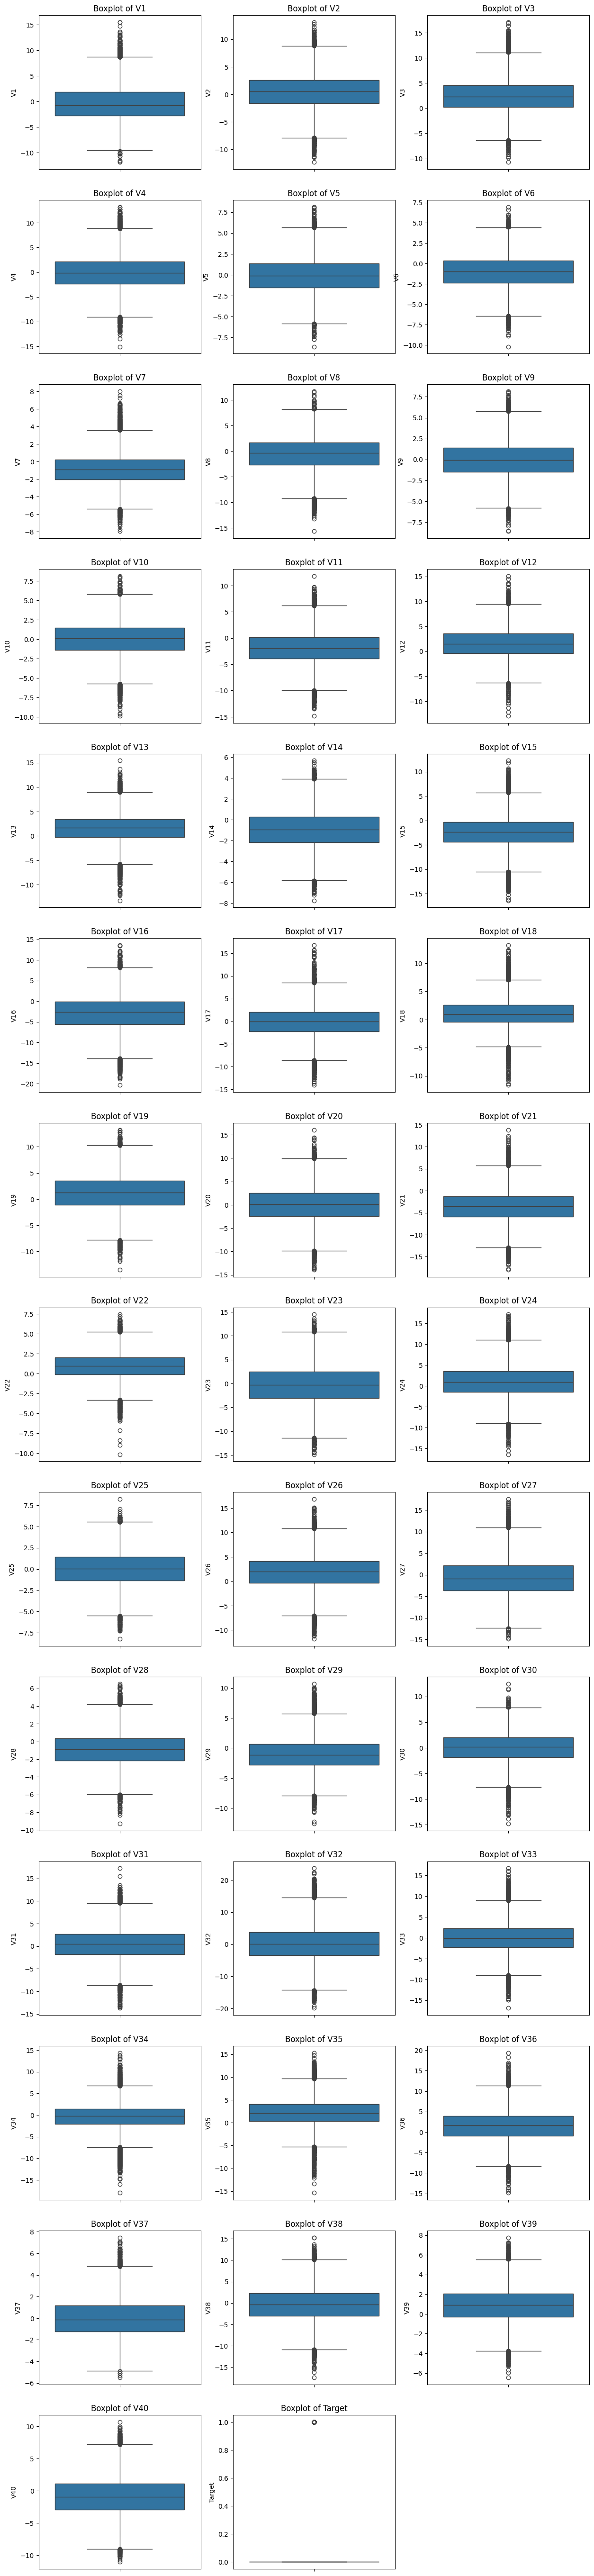

In [ ]:
plt.figure(figsize=(15, 70))


for i, col in enumerate(train_df.columns):
    plt.subplot(14, 3, i + 1)
    sns.boxplot(data=train_df, y=col)
    plt.title(f'Boxplot of {col}')

#### Distribution Check
It seems almost all variables are normally distributed, with many being distributed with a mean of 0. However, because almost all (or all) variables are normally distributed, we must check if any variables share a high correlation.

## Bivariate Analysis

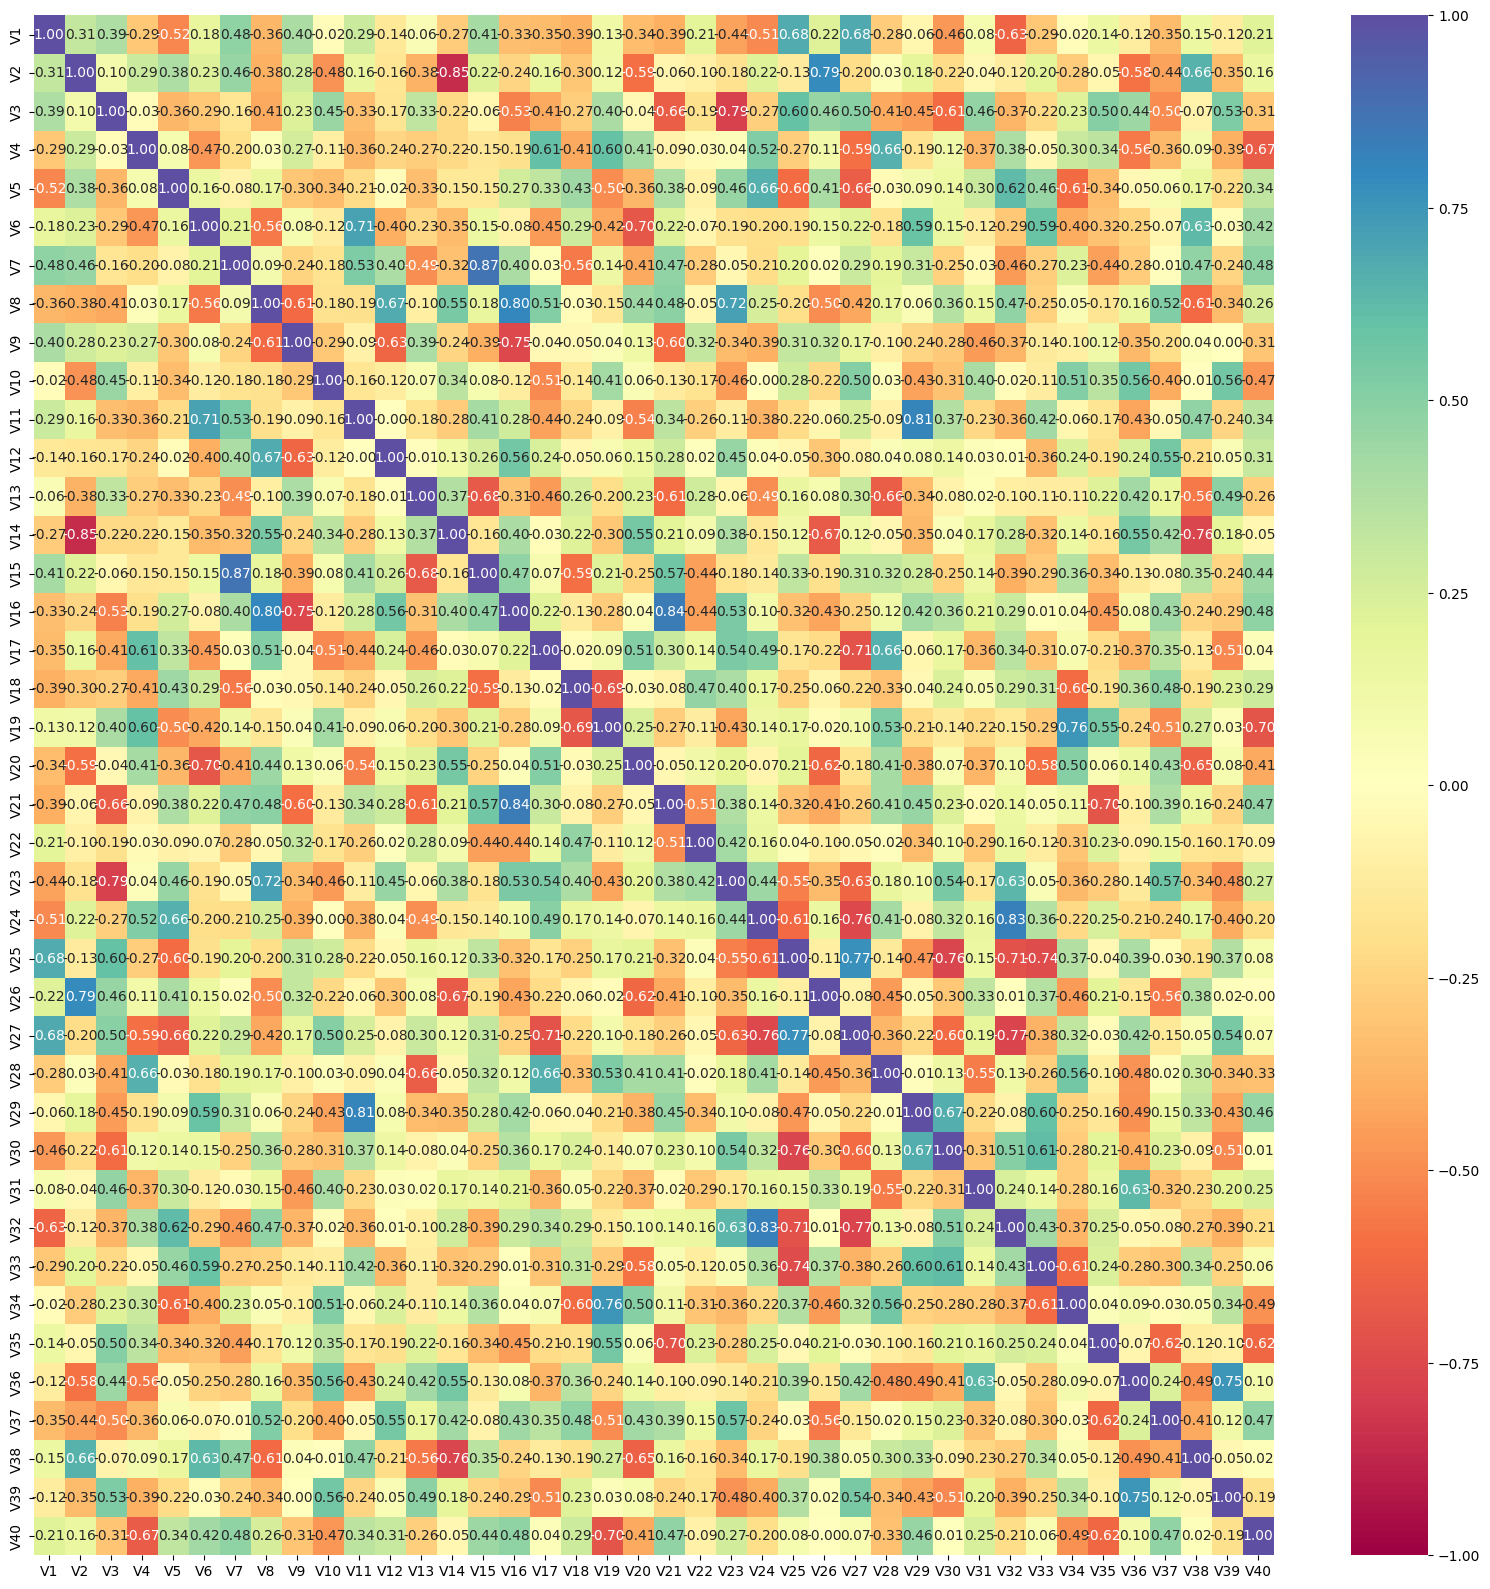

In [ ]:
cols_list = train_df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    train_df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

Some variables seem to be highly correlated with each other.

Variables with over |0.8| correlation:
* V2 and V14 have -0.85 correlation
* V8 and V16 have +0.80 correlation
* V11 and V29 have +0.81 correlation
* V24 and v32 have +0.83 correlation

\*Many other variables have high correlations (0.6-0.7)

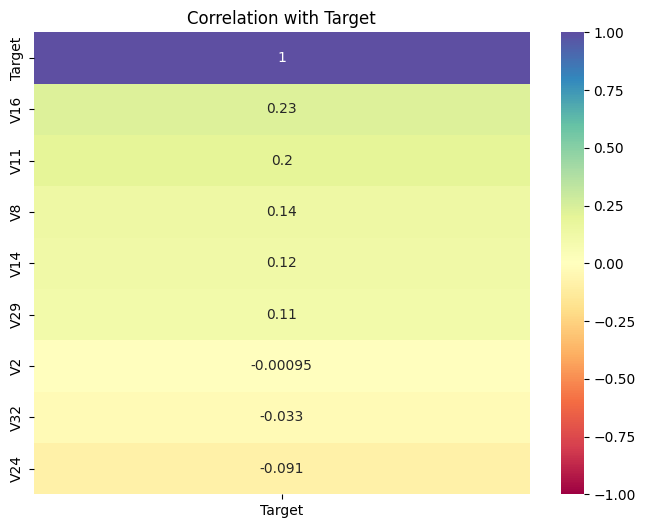

In [ ]:
# check for correlation between the highly correlated variables with the target
corr_cols = ["V2", "V14", "V8", "V16", "V11", "V29", "V24", "V32"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    train_df[corr_cols + ["Target"]].corr()[["Target"]].sort_values(by="Target", ascending=False),
    annot=True,
    vmin=-1,
    vmax=1,
    cmap="Spectral"
)
plt.title("Correlation with Target")
plt.show()

# **Data Preprocessing**

In [ ]:
# drop rows with null values in V1 and V2
train_df_clean = train_df.dropna(subset=['V1', 'V2'])
test_df_clean = test_df.dropna(subset=['V1', 'V2'])

# split train and test data into x and y
train_x, train_y = train_df_clean.drop(columns=["Target"]), train_df_clean["Target"]
test_x, test_y = test_df_clean.drop(columns=["Target"]), test_df_clean["Target"]

# split train into train and validation
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y,
                                                  test_size=0.2, random_state=11)

# oversample from the target variable in our training set ONLY
smote = SMOTE(random_state=11)
train_x, train_y = smote.fit_resample(train_x, train_y)

# turn y into categorical vector
train_y = tf.keras.utils.to_categorical(train_y, num_classes=2)
val_y = tf.keras.utils.to_categorical(val_y, num_classes=2)
test_y = tf.keras.utils.to_categorical(test_y, num_classes=2)

print(train_x.shape)

(30156, 40)


#### Preprocessing Steps
1. No need for outlier removal as data does not have extreme outliers
2. Remove the rows with null values
3. Because the correlated variables have varying correlation with the target, choose to keep them in our dataset

# **Model Building**

## Model Evaluation Criterion

The most important thing to catch are False Negatives, so recall score is the most important. While a FP does incure extra cost, it is much less costly than a FN, so f-1 score is still important to consider, but recall score will be our main evaluation criteria.

\*Note: still be training with accuracy score for our loss function

In [ ]:
def evaluate_model(model, x_test, y_test):
  """
  returns dataframe of accuracy, recall, precision, and f1 score of model

  model: the model
  x_text: test set features
  y_test: test set targets
  """

  pred = model.predict(x_test)

  # Convert one-hot encoded targets and predictions to 1D class labels
  pred_classes = np.argmax(pred, axis=1)
  target_classes = np.argmax(y_test, axis=1)

  acc = accuracy_score(target_classes, pred_classes)
  recall = recall_score(target_classes, pred_classes, average='macro')
  precision = precision_score(target_classes, pred_classes, average='macro')
  f1 = f1_score(target_classes, pred_classes, average='macro')

  # creating a dataframe of metrics
  df_perf = pd.DataFrame(
      {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1}, index=[0]
  )

  return df_perf

In [ ]:
def plot_loss_acc(history, title):
  """
  plots the loss and accuracy of the model

  history: the history of the model
  title: the title of the plot
  """

  fig, ax = plt.subplots()
  plt.plot(history.history[title])
  plt.plot(history.history['val_'+title])

  plt.title('Model ' + title)
  plt.ylabel(title)
  plt.xlabel('Epoch')
  fig.legend(['Train', 'Validation'], loc="outside right upper")

In [ ]:
epochs = 50
batch_size = 64

tf.keras.backend.clear_session()

## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [ ]:
model_0 = tf.keras.Sequential()
model_0.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(40,)))
model_0.add(tf.keras.layers.Dense(2, activation='softmax'))

model_0.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9201 - loss: 0.2513 - val_accuracy: 0.9654 - val_loss: 0.1569
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9434 - loss: 0.1879 - val_accuracy: 0.8390 - val_loss: 0.3373
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9478 - loss: 0.1699 - val_accuracy: 0.9669 - val_loss: 0.1559
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9498 - loss: 0.1593 - val_accuracy: 0.9712 - val_loss: 0.1332
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9514 - loss: 0.1517 - val_accuracy: 0.9775 - val_loss: 0.1081
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9527 - loss: 0.1454 - val_accuracy: 0.9567 - val_loss: 0.1886
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9536 - loss: 0.1398 - val_accuracy: 0.9747 - val_loss: 0.1373
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9552 - loss: 0.1347 - val_accuracy: 0.

,Accuracy,Recall,Precision,F1 Score
0,0.955172,0.917661,0.77408,0.827842


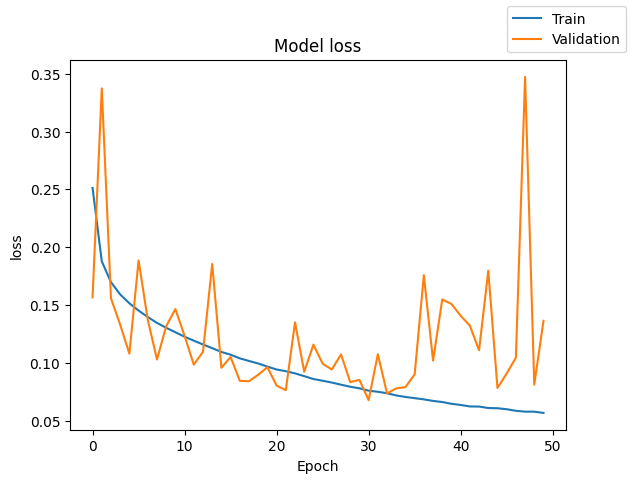

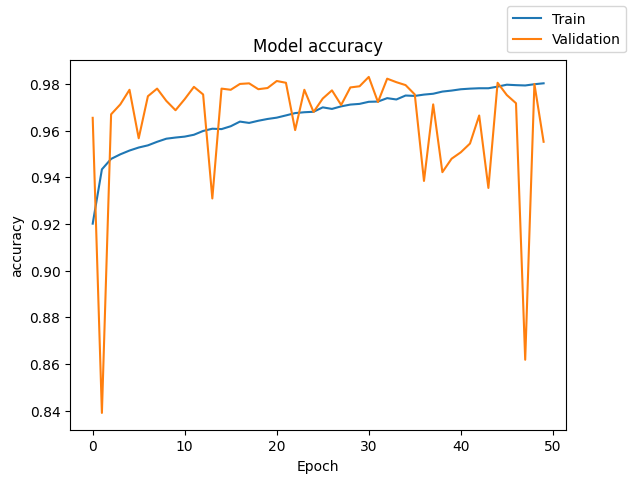

In [ ]:
# train our model
start = time.time()
history = model_0.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()


---Took 79.0804512500763 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.976588,0.976588,0.976683,0.976587


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.955172,0.917661,0.77408,0.827842


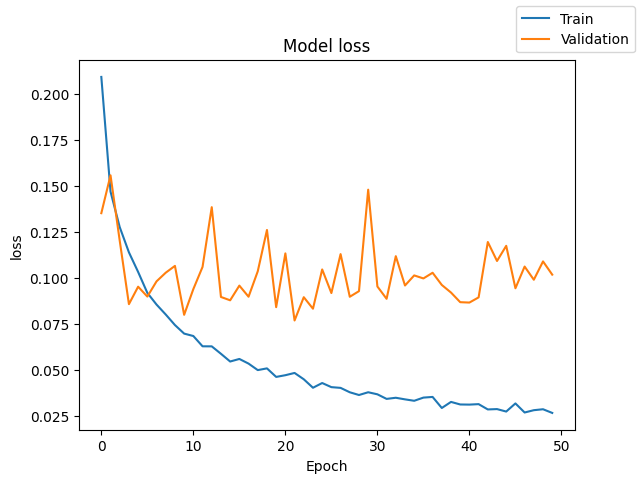

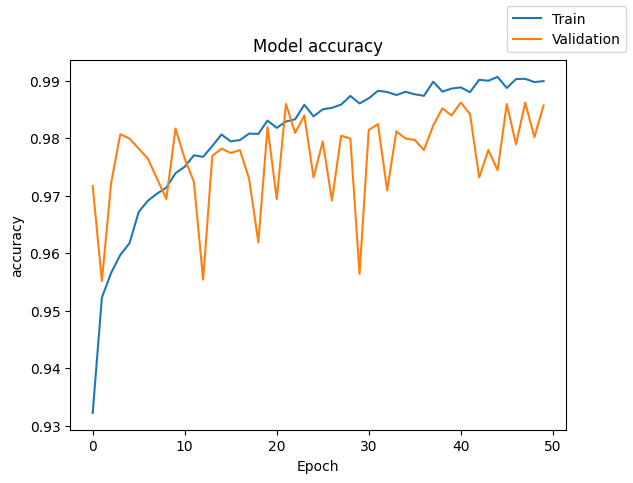

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_0_train_perf = evaluate_model(model_0, train_x, train_y)
display(model_0_train_perf)
model_0_val_perf = evaluate_model(model_0, val_x, val_y)
display(model_0_val_perf)

Decent performance, with 0.955 acc, 0.917 recall.

However, there was extreme oscilation with the validation data, a sign that our optimizer can be improved on. There also seems to be overfitting.

# **Model Performance Improvement**

## Model 1

In [ ]:
# implement AdamW as optimizer
model_1 = tf.keras.Sequential()
model_1.add(tf.keras.layers.Dense(128, activation='relu', input_shape=(40,)))
model_1.add(tf.keras.layers.Dense(2, activation='softmax'))

model_1.compile(optimizer='adamw', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_1.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9323 - loss: 0.2094 - val_accuracy: 0.9717 - val_loss: 0.1353
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9523 - loss: 0.1470 - val_accuracy: 0.9552 - val_loss: 0.1559
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9566 - loss: 0.1277 - val_accuracy: 0.9722 - val_loss: 0.1203
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9597 - loss: 0.1140 - val_accuracy: 0.9807 - val_loss: 0.0858
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9618 - loss: 0.1033 - val_accuracy: 0.9800 - val_loss: 0.0953
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9672 - loss: 0.0920 - val_accuracy: 0.9782 - val_loss: 0.0899
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.0856 - val_accuracy: 0.9765 - val_loss: 0.0982
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9704 - loss: 0.0802 - val_accuracy: 0.

---Took 79.0804512500763 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.98982,0.98982,0.989927,0.989819


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985725,0.922957,0.936247,0.929485


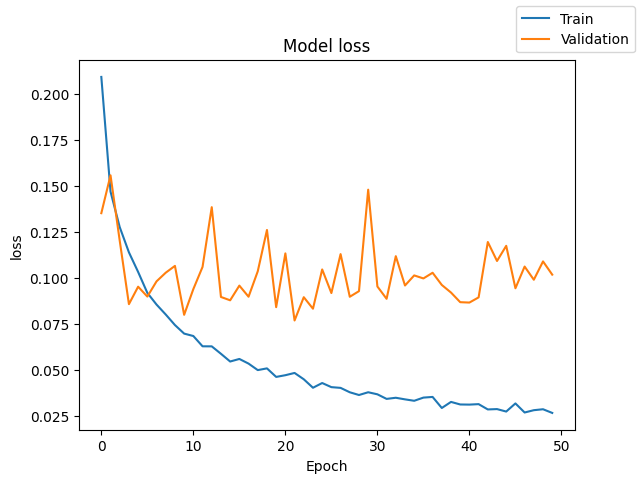

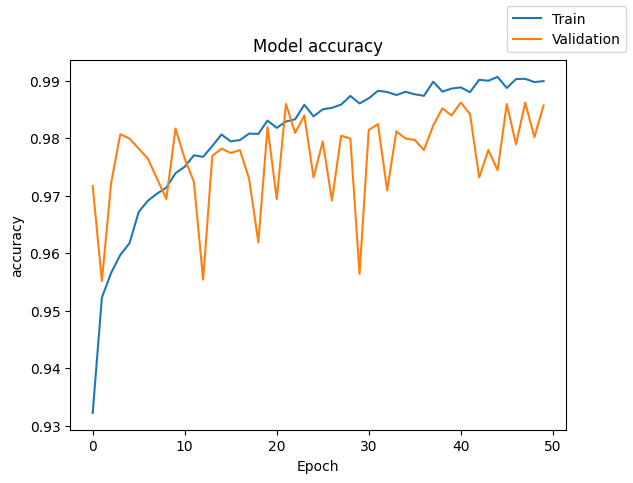

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_1_train_perf = evaluate_model(model_1, train_x, train_y)
display(model_1_train_perf)
model_1_val_perf = evaluate_model(model_1, val_x, val_y)
display(model_1_val_perf)

Much better accuracies, but our model still struggles with overfitting as our validation loss is much higher than our training loss

## Model 2

In [ ]:
# We add a second hidden layer with he_normal initializer
model_2 = tf.keras.Sequential()
model_2.add(tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(40,)))
model_2.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu'))
model_2.add(tf.keras.layers.Dense(2, activation='softmax'))

model_2.compile(optimizer='adamw', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_2.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9723 - loss: 0.1340 - val_accuracy: 0.9880 - val_loss: 0.0655
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9899 - loss: 0.0552 - val_accuracy: 0.9885 - val_loss: 0.0621
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0490 - val_accuracy: 0.9895 - val_loss: 0.0644
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9917 - loss: 0.0435 - val_accuracy: 0.9885 - val_loss: 0.0576
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.0423 - val_accuracy: 0.9890 - val_loss: 0.0563
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9914 - loss: 0.0407 - val_accuracy: 0.9877 - val_loss: 0.0658
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0400 - val_accuracy: 0.9887 - val_loss: 0.0590
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9934 - loss: 0.0331 - val_accuracy: 0.

---Took 56.70390295982361 seconds---
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.998623,0.989789,0.997128,0.993428


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985975,0.918746,0.941854,0.929948


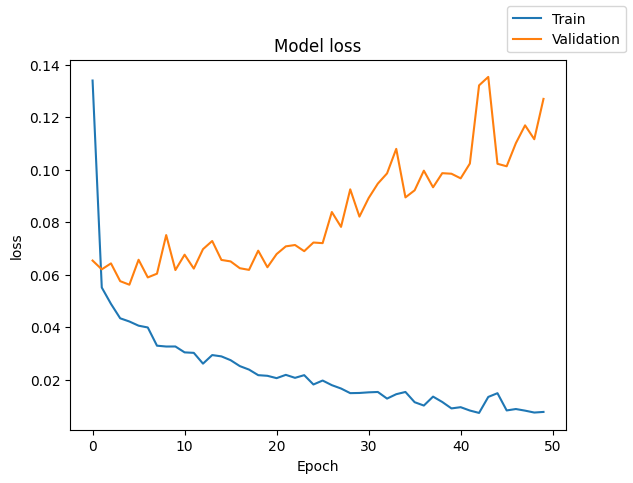

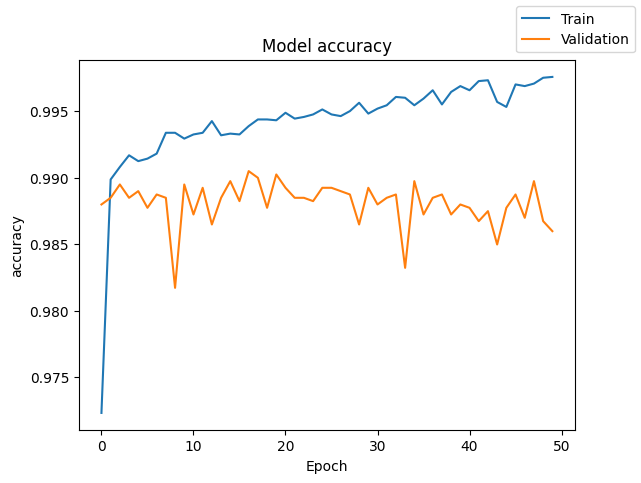

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_2_train_perf = evaluate_model(model_2, train_x, train_y)
display(model_2_train_perf)
model_2_val_perf = evaluate_model(model_2, val_x, val_y)
display(model_2_val_perf)

Our models seem to struggle with overfitting. (The model validation loss is actually increasing in subsequent epochs) Recall also drops from 99 to 91 percent from training to validation.

## Model 3

In [ ]:
# We add dropoff
model_3 = tf.keras.Sequential()
model_3.add(tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(40,)))
model_3.add(tf.keras.layers.Dropout(0.2))
model_3.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu'))
model_3.add(tf.keras.layers.Dropout(0.2))
model_3.add(tf.keras.layers.Dense(2, activation='softmax'))

model_3.compile(optimizer='adamw', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_3.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8962 - loss: 0.3630 - val_accuracy: 0.9860 - val_loss: 0.1003
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9444 - loss: 0.1695 - val_accuracy: 0.9862 - val_loss: 0.1190
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9523 - loss: 0.1425 - val_accuracy: 0.9857 - val_loss: 0.0993
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9558 - loss: 0.1266 - val_accuracy: 0.9862 - val_loss: 0.0908
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9595 - loss: 0.1140 - val_accuracy: 0.9735 - val_loss: 0.1156
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9611 - loss: 0.1081 - val_accuracy: 0.9835 - val_loss: 0.0888
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9625 - loss: 0.0992 - val_accuracy: 0.9842 - val_loss: 0.0784
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9650 - loss: 0.0927 - val_accuracy: 0.

---Took 102.87386798858643 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.998623,0.989789,0.997128,0.993428


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985975,0.918746,0.941854,0.929948


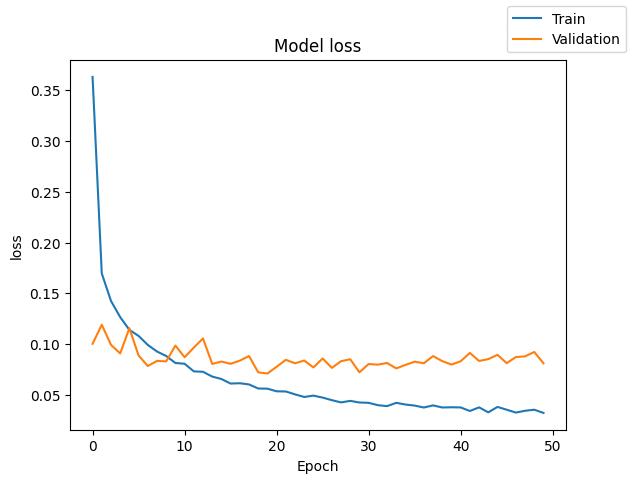

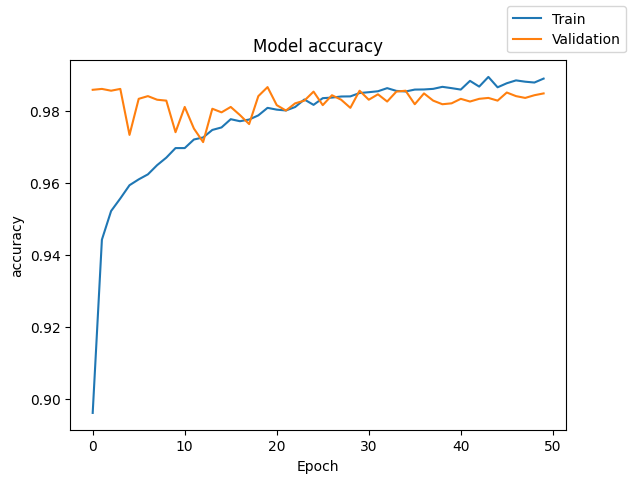

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_3_train_perf = evaluate_model(model_3, train_x, train_y)
display(model_2_train_perf)
model_3_val_perf = evaluate_model(model_3, val_x, val_y)
display(model_2_val_perf)

We have done much better with oscillations and fixes the increasing validation loss, however our model seems to "learn" extremely quickly casuing overfitting, with our validation accuracies plateuing extremely quickly.

## Model 4

In [ ]:
# reduce learning rate
model_4 = tf.keras.Sequential()
model_4.add(tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(40,)))
model_4.add(tf.keras.layers.Dropout(0.2))
model_4.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal', activation='relu'))
model_4.add(tf.keras.layers.Dropout(0.2))
model_4.add(tf.keras.layers.Dense(2, activation='softmax'))

model_4.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.00005), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_4.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6926 - loss: 1.2108 - val_accuracy: 0.8993 - val_loss: 0.2731
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8216 - loss: 0.6063 - val_accuracy: 0.9344 - val_loss: 0.1906
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8573 - loss: 0.4756 - val_accuracy: 0.9512 - val_loss: 0.1528
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8737 - loss: 0.4060 - val_accuracy: 0.9594 - val_loss: 0.1295
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8849 - loss: 0.3604 - val_accuracy: 0.9662 - val_loss: 0.1182
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8988 - loss: 0.3179 - val_accuracy: 0.9720 - val_loss: 0.1058
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9041 - loss: 0.2847 - val_accuracy: 0.9765 - val_loss: 0.1038
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9092 - loss: 0.2714 - val_accuracy: 0.

---Took 108.09263753890991 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.971647,0.971647,0.972539,0.971634


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985975,0.940463,0.925704,0.93294


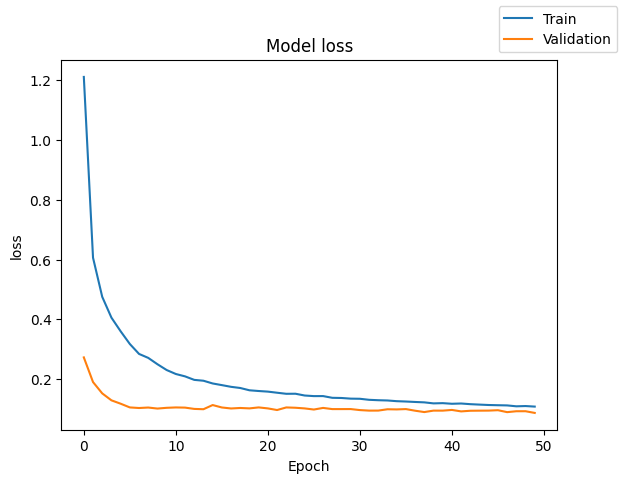

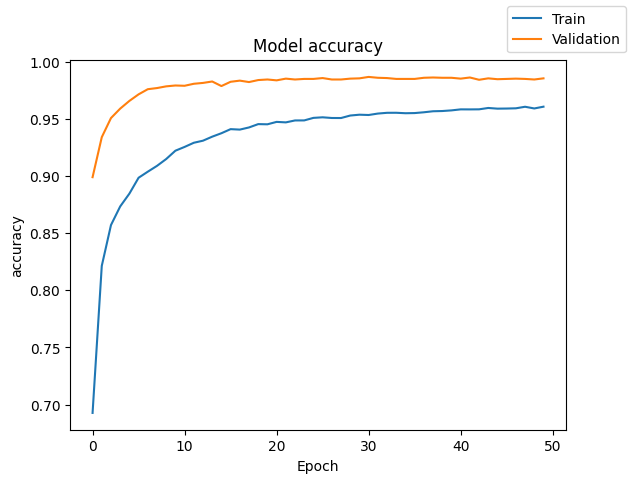

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_4_train_perf = evaluate_model(model_4, train_x, train_y)
display(model_4_train_perf)
model_4_val_perf = evaluate_model(model_4, val_x, val_y)
display(model_4_val_perf)

Much less overfitting, however it seems our overall accuracy does decrease since our learning rate is too small. Suprisingly our overall accuracy was higher in our validation set compared to our test set, pointing to possible underfitting! (most likley from decreasing lr by 100x)

## Model 5

In [ ]:
# use regularization, batch normalization, and slightly decrease our learning rate
model_5 = tf.keras.Sequential()

# Hidden Layer 1 (Dense -> BatchNorm -> ReLU)
model_5.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal', input_shape=(40,)))
model_5.add(tf.keras.layers.BatchNormalization())
model_5.add(tf.keras.layers.Activation('relu'))

# Hidden Layer 2 (Dense -> BatchNorm -> ReLU)
model_5.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal'))
model_5.add(tf.keras.layers.BatchNormalization())
model_5.add(tf.keras.layers.Activation('relu'))

# Output Layer
model_5.add(tf.keras.layers.Dense(2, activation='softmax'))

model_5.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0002), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_5.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9092 - loss: 0.2597 - val_accuracy: 0.9725 - val_loss: 0.1457
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9481 - loss: 0.1604 - val_accuracy: 0.9802 - val_loss: 0.1055
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9544 - loss: 0.1355 - val_accuracy: 0.9827 - val_loss: 0.0989
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9584 - loss: 0.1179 - val_accuracy: 0.9795 - val_loss: 0.1061
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9619 - loss: 0.1061 - val_accuracy: 0.9842 - val_loss: 0.0864
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9641 - loss: 0.0968 - val_accuracy: 0.9857 - val_loss: 0.0843
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9676 - loss: 0.0900 - val_accuracy: 0.9832 - val_loss: 0.0886
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9690 - loss: 0.0824 - val_accuracy: 0.

---Took 117.50092577934265 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.997745,0.997745,0.997748,0.997745


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.987979,0.930664,0.950276,0.940222


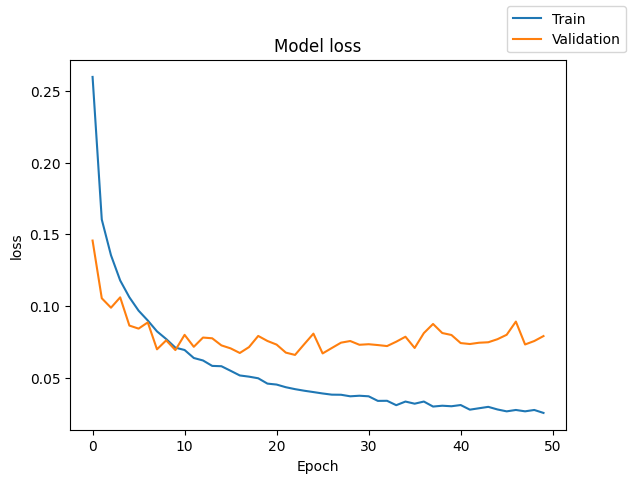

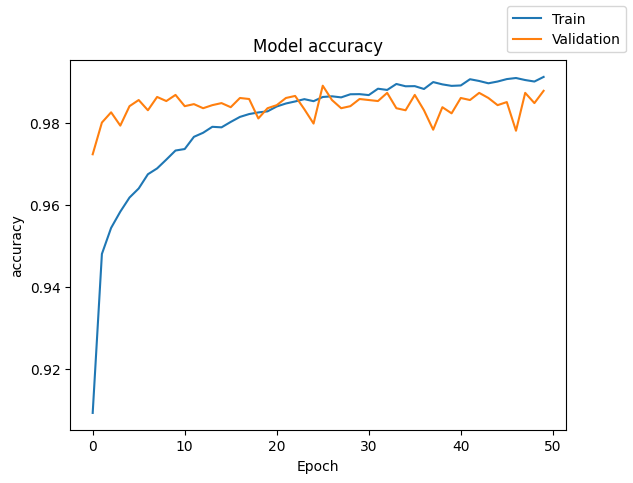

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_5_train_perf = evaluate_model(model_5, train_x, train_y)
display(model_5_train_perf)
model_5_val_perf = evaluate_model(model_5, val_x, val_y)
display(model_5_val_perf)

Increased our overall accuracy, but some overfitting seems to be brought back due to the removal of the dropout layers. (Recall however decreased from 94% to 93% on the validation)

## Model 6

In [ ]:
# add back the dropout, correcting the order with normalization
model_6 = tf.keras.Sequential()

# Hidden Layer 1 (Dense -> BatchNorm -> ReLU -> Dropout)
model_6.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal', input_shape=(40,)))
model_6.add(tf.keras.layers.BatchNormalization())
model_6.add(tf.keras.layers.Activation('relu'))
model_6.add(tf.keras.layers.Dropout(0.2))

# Hidden Layer 2 (Dense -> BatchNorm -> ReLU -> Dropout)
model_6.add(tf.keras.layers.Dense(128, kernel_initializer='he_normal'))
model_6.add(tf.keras.layers.BatchNormalization())
model_6.add(tf.keras.layers.Activation('relu'))
# Output Layer
model_6.add(tf.keras.layers.Dense(2, activation='softmax'))

model_6.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# train our model
start = time.time()
history = model_6.fit(train_x, train_y, validation_data=(val_x, val_y) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9042 - loss: 0.2636 - val_accuracy: 0.9772 - val_loss: 0.1348
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9443 - loss: 0.1703 - val_accuracy: 0.9845 - val_loss: 0.0964
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9509 - loss: 0.1440 - val_accuracy: 0.9830 - val_loss: 0.0951
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9556 - loss: 0.1306 - val_accuracy: 0.9837 - val_loss: 0.0903
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9562 - loss: 0.1228 - val_accuracy: 0.9840 - val_loss: 0.0922
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9584 - loss: 0.1139 - val_accuracy: 0.9875 - val_loss: 0.0797
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9598 - loss: 0.1094 - val_accuracy: 0.9872 - val_loss: 0.0801
Epoch 8/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9615 - loss: 0.1059 - val_accuracy: 0.

---Took 129.364750623703 seconds---
943/943 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.995457,0.995457,0.995471,0.995457


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.985475,0.940198,0.921924,0.93084


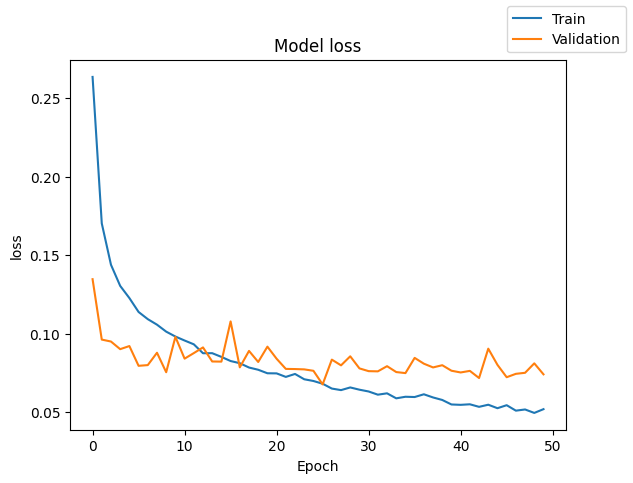

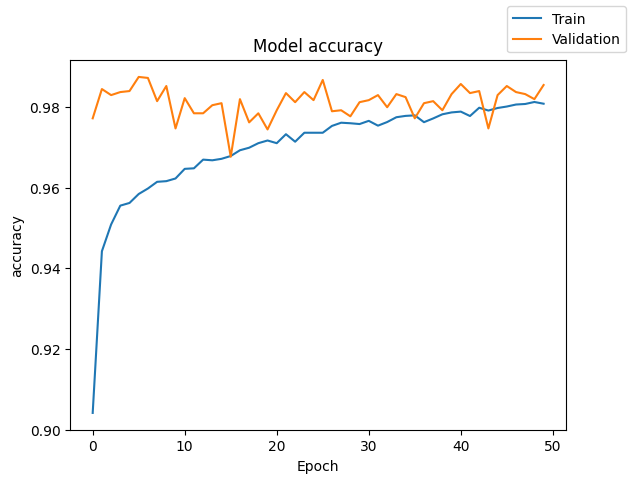

In [ ]:
# results/evaluation
print(f"---Took {end-start} seconds---")
plot_loss_acc(history, 'loss')
plot_loss_acc(history, 'accuracy')

model_6_train_perf = evaluate_model(model_6, train_x, train_y)
display(model_6_train_perf)
model_6_val_perf = evaluate_model(model_6, val_x, val_y)
display(model_6_val_perf)

There seems to be some oscillations with our validation, but overall the recall has improved back to the 94% of our model 4, but this time model 6 also performs well on the training data set.

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [ ]:
# df of all model training and validations
all_models_perf = pd.concat([
    model_0_train_perf.assign(Model='Model 0 Train'),
    model_0_val_perf.assign(Model='Model 0 Val'),
    model_1_train_perf.assign(Model='Model 1 Train'),
    model_1_val_perf.assign(Model='Model 1 Val'),
    model_2_train_perf.assign(Model='Model 2 Train'),
    model_2_val_perf.assign(Model='Model 2 Val'),
    model_3_train_perf.assign(Model='Model 3 Train'),
    model_3_val_perf.assign(Model='Model 3 Val'),
    model_4_train_perf.assign(Model='Model 4 Train'),
    model_4_val_perf.assign(Model='Model 4 Val'),
    model_5_train_perf.assign(Model='Model 5 Train'),
    model_5_val_perf.assign(Model='Model 5 Val'),
    model_6_train_perf.assign(Model='Model 6 Train'),
    model_6_val_perf.assign(Model='Model 6 Val')
], ignore_index=True)

# Reorder columns to have 'Model' first
cols = ['Model'] + [col for col in all_models_perf.columns if col != 'Model']
all_models_perf = all_models_perf[cols]

display(all_models_perf)

,Model,Accuracy,Recall,Precision,F1 Score
0,Model 0 Train,0.976588,0.976588,0.976683,0.976587
1,Model 0 Val,0.955172,0.917661,0.774080,0.827842
2,Model 1 Train,0.989820,0.989820,0.989927,0.989819
3,Model 1 Val,0.985725,0.922957,0.936247,0.929485
4,Model 2 Train,0.998623,0.989789,0.997128,0.993428
5,Model 2 Val,0.985975,0.918746,0.941854,0.929948
6,Model 3 Train,0.997679,0.997679,0.997679,0.997679
7,Model 3 Val,0.984974,0.937762,0.919588,0.928455
8,Model 4 Train,0.971647,0.971647,0.972539,0.971634
9,Model 4 Val,0.985975,0.940463,0.925704,0.932940


We will choose model 6 as it has a strong performance of around 94% on the validation set while also having extremely strong performance on the train set data.

Now, let's check the performance of the final model on the test set.

In [ ]:
# Evaluate the final model on the test set
model_6_test_perf = evaluate_model(model_6, test_x, test_y)
print("Model 6 Test Performance:")
display(model_6_test_perf)

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 6 Test Performance:


,Accuracy,Recall,Precision,F1 Score
0,0.980958,0.926569,0.901263,0.913469


The final model does seem to have small amounts of overfitting, as recall decreased to 92.66%, but the overall accuracy of 98% is very good.

# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

#### Actionable Insights:
* If using this model, find ways to reduce cost of inspection, since this model was trained to reduce recall, but has relatively poor (90%) on precision.
* Do more experiments to bring up precision and recall performance in general as there is still some overfitting in the current model.
#### Recommendations:
* Offer stronger guarantees for working generators as we have a model that accurately predict a large majority of "Failure" generators.


In [ ]:
# convert to html
!jupyter nbconvert --execute --to html "/content/INN_ReneWind_Main_Project_FullCode_Notebook (1).ipynb"

[NbConvertApp] Converting notebook /content/INN_ReneWind_Main_Project_FullCode_Notebook (1).ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
2026-05-07 21:31:23.449228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to registe